Performs logistic regression on `skill.txt`, a CSV generated by `bin/scratch.rs` with the following:

- `black_rollouts` number of MCTS rollouts performed by the black player (goes first)
- `white_rollouts` number of MCTS rollouts performed by the white player (goes second)
- `log_skill_ratio` log of the ratio of the above
- `result` 1 or 0 depending on whether black won

Matchups were generated randomly with $121^X$ rollouts per player, where $X$ is selected uniformly from $1.5$ to $3.5$. $X$ is expected to be roughly proportional to the depth of the tree explored by that player.

In [1]:
import csv
import numpy as np

xs = []
ys = []
with open('skill.txt') as f:
    reader = csv.DictReader(f)
    for row in reader:
        xs.append(float(row['log_skill_ratio']))
        ys.append(float(row['result']))

xs = np.array(xs)
ys = np.array(ys)

print(np.stack([xs, ys]).T)

[[-0.25294927  0.        ]
 [-0.0092198   0.        ]
 [ 1.94567487  1.        ]
 ...
 [ 6.46048562  1.        ]
 [-1.02350986  1.        ]
 [ 5.08285728  1.        ]]


In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xs.reshape((-1, 1)), ys)
model.n_iter_

array([6], dtype=int32)

b0 = 0.28621449516690256
b1 = 0.9517552612592354


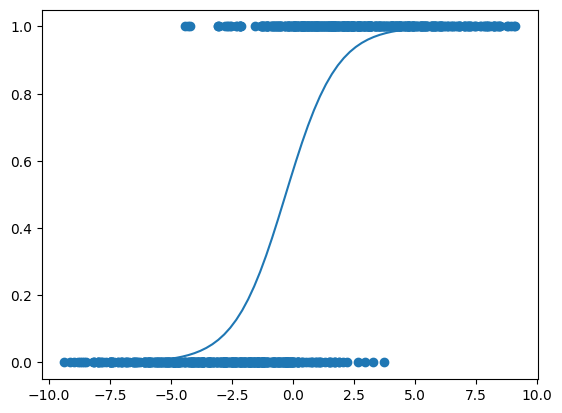

In [3]:
import matplotlib.pyplot as plt

b0 = model.intercept_[0]
b1 = model.coef_[0,0]
print('b0 =', b0)
print('b1 =', b1)

def predict(x):
    return 1. / (1. + np.exp(-(b0 + b1 * x)))

x = np.linspace(-6, 6)
y = predict(x)
plt.plot(x, y)
plt.scatter(xs, ys)
plt.show()

In [4]:
x = np.arange(-5, 5)
y = predict(x)
print(np.stack([x, y]).T)

[[-5.          0.01128913]
 [-4.          0.02872598]
 [-3.          0.07115698]
 [-2.          0.16557812]
 [-1.          0.33949606]
 [ 0.          0.57106913]
 [ 1.          0.77521042]
 [ 2.          0.89932301]
 [ 3.          0.95857171]
 [ 4.          0.98358867]]


In [6]:
def to_mcts(x):
    return np.exp(x)
def to_elo(x):
    return 400.0 / np.log(10) * (b0 + b1 * x)

x = np.arange(0, 5, 0.5)
y = to_elo(x)+1200
x = to_mcts(x)*100000
print(f'{'ROLLOUTS':>10} {'ELO':>10}')
for x, y in zip(x, y):
    print(f'{x:10.0f} {y:10.0f}')

  ROLLOUTS        ELO
    100000       1250
    164872       1332
    271828       1415
    448169       1498
    738906       1580
   1218249       1663
   2008554       1746
   3311545       1828
   5459815       1911
   9001713       1994


The above table shows the effective Elo rating of the black player when using the given number of rollouts and playing against a white player with elo 1200 and using 100,000 rollouts.